# Readmission Analysis

A thin notebook for exploration and storytelling. All reusable model logic lives in `src/`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "patients.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_and_clean
from src.eda import missing_value_report, numeric_summary, plot_numeric_distributions, plot_target_rate_by
from src.evaluation import plot_confusion_matrix, results_table
from src.io import save_model
from src.models import make_logistic_regression, make_random_forest
from src.preprocess import build_preprocessor, clean_bmi, clean_creatinine
from src.training import cross_validate_estimator, fit_and_evaluate

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = PROJECT_ROOT / "data" / "patients.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts"
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
TARGET_COL = "readmission_30d"
NUMERIC_COLS = [
    "age",
    "bmi",
    "num_prior_admissions",
    "length_of_stay",
    "lab_sodium",
    "lab_creatinine",
    "bmi_implausible",
    "lab_creatinine_negative",
]
CATEGORICAL_COLS = ["sex", "diagnosis_code", "hospital_id"]
FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS

## Load + EDA Summary

Load the data once, apply the row-preserving cleaning flags, and inspect the dataset through reusable summary helpers.

In [2]:
df = load_and_clean(DATA_PATH)
df = clean_creatinine(clean_bmi(df))

pd.DataFrame(
    {
        "metric": ["rows", "columns", "date_min", "date_max", "target_rate"],
        "value": [
            len(df),
            df.shape[1],
            df["admission_date"].min().date(),
            df["admission_date"].max().date(),
            f"{df[TARGET_COL].mean():.1%}",
        ],
    }
)

,metric,value
0,rows,2000
1,columns,14
2,date_min,2023-01-01
3,date_max,2024-11-30
4,target_rate,19.9%


In [3]:
missing_value_report(df).style.format({"missing_percentage": "{:.1f}%"})

,missing_count,missing_percentage
lab_creatinine,436,21.8%
lab_sodium,303,15.2%
bmi,242,12.1%
age,60,3.0%
sex,25,1.2%
patient_id,0,0.0%
num_prior_admissions,0,0.0%
length_of_stay,0,0.0%
diagnosis_code,0,0.0%
hospital_id,0,0.0%


In [4]:
numeric_summary(df[NUMERIC_COLS + [TARGET_COL]]).style.format(precision=2)

,min,max,mean,median,std
age,18.00,95.00,55.93,56.00,22.22
bmi,14.00,50.33,27.36,27.26,5.43
num_prior_admissions,0.00,7.00,1.55,1.00,1.25
length_of_stay,1.00,24.00,6.00,5.00,3.47
lab_sodium,128.11,150.57,139.07,139.12,3.59
lab_creatinine,0.05,2.64,1.00,0.99,0.39
readmission_30d,0.00,1.00,0.20,0.00,0.40


## Exploratory Plots

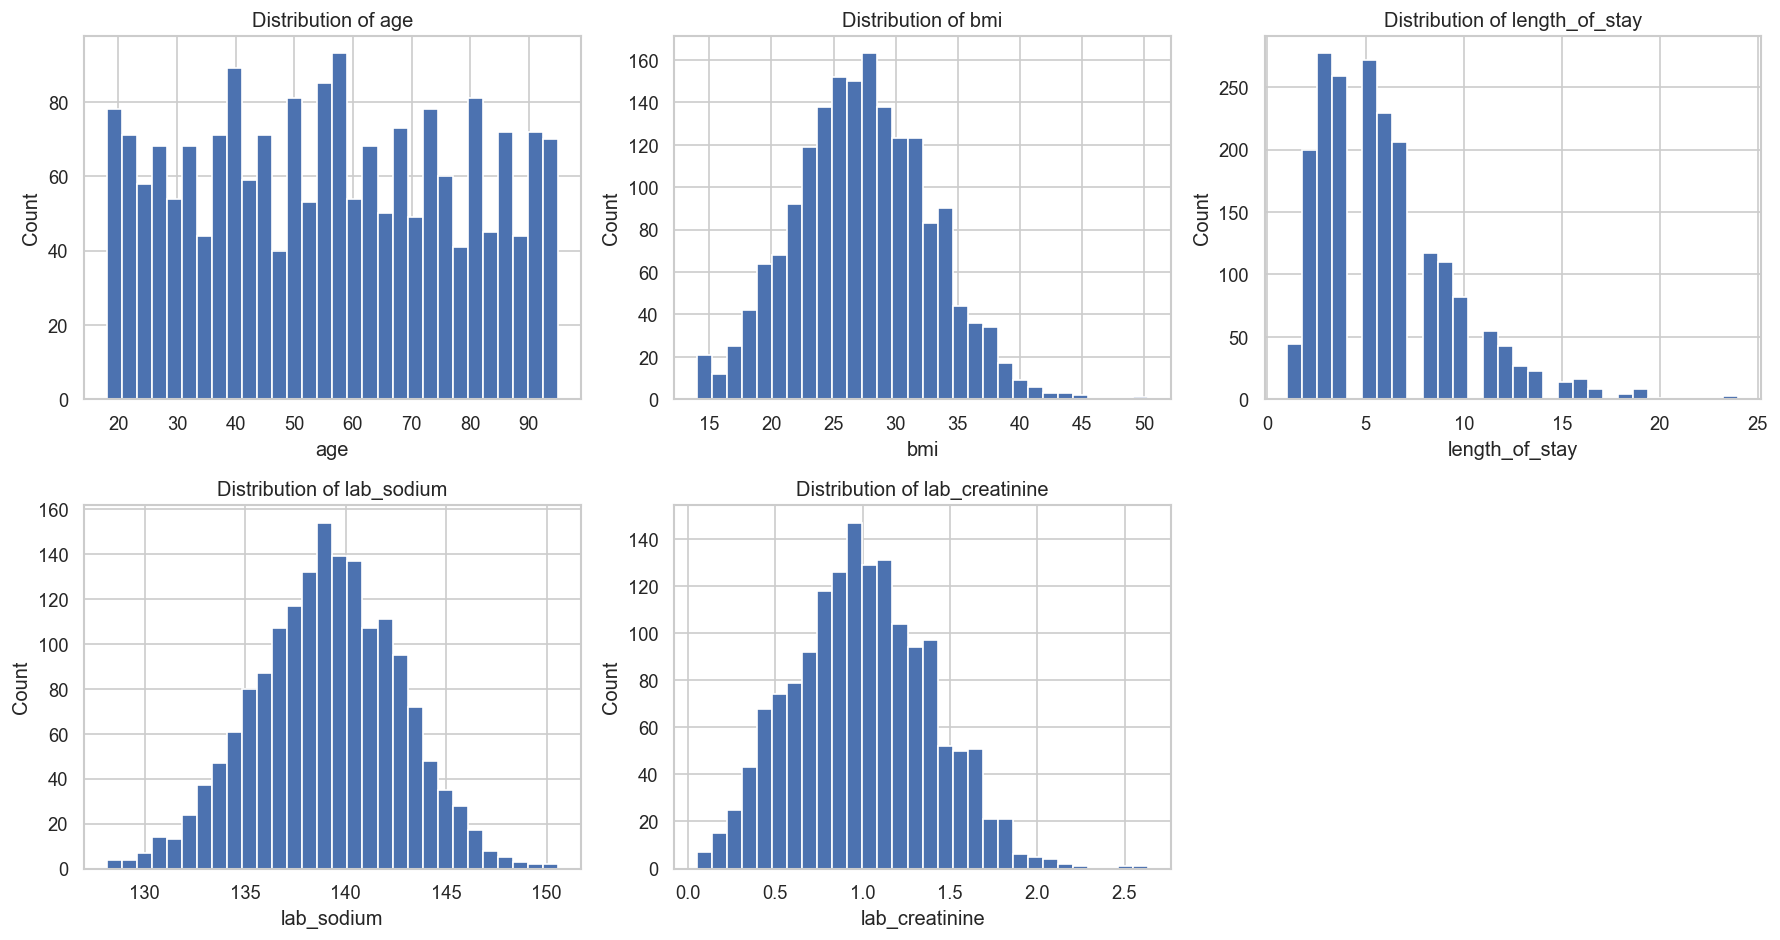

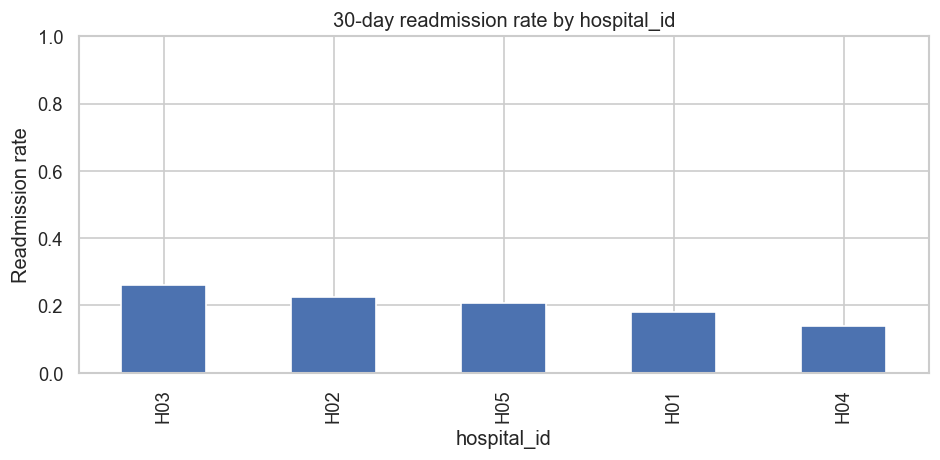

In [5]:
plot_numeric_distributions(df, ["age", "bmi", "length_of_stay", "lab_sodium", "lab_creatinine"])
plot_target_rate_by(df, "hospital_id")

## Shared Preprocessing Path

The same `ColumnTransformer` is reused for both models so training and validation follow one consistent path.

In [6]:
preprocessor = build_preprocessor(NUMERIC_COLS, CATEGORICAL_COLS)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## Train + Evaluate Logistic Regression

In [7]:
logreg_result = fit_and_evaluate(
    df=df,
    feature_cols=FEATURE_COLS,
    preprocessor=preprocessor,
    estimator=make_logistic_regression(random_state=RANDOM_STATE),
    target_col=TARGET_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
logreg_result

TrainingResult(model_name='LogisticRegression', pipeline=Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'num_prior_admissions',
                                                   'length_of_stay',
                                                   'lab_sodium',
                                                   'lab_creatinine',
                                                   'bmi_implausible',
                                                   'lab_creatinine_negative']),
           

## Train + Evaluate Random Forest

In [8]:
rf_result = fit_and_evaluate(
    df=df,
    feature_cols=FEATURE_COLS,
    preprocessor=preprocessor,
    estimator=make_random_forest(random_state=RANDOM_STATE),
    target_col=TARGET_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
rf_result

TrainingResult(model_name='RandomForestClassifier', pipeline=Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'num_prior_admissions',
                                                   'length_of_stay',
                                                   'lab_sodium',
                                                   'lab_creatinine',
                                                   'bmi_implausible',
                                                   'lab_creatinine_negative']),
       

## Cross-Validation Summary

In [9]:
logreg_cv = cross_validate_estimator(
    df=df,
    feature_cols=FEATURE_COLS,
    preprocessor=preprocessor,
    estimator=make_logistic_regression(random_state=RANDOM_STATE),
    target_col=TARGET_COL,
    cv=CV_FOLDS,
    random_state=RANDOM_STATE,
)
rf_cv = cross_validate_estimator(
    df=df,
    feature_cols=FEATURE_COLS,
    preprocessor=preprocessor,
    estimator=make_random_forest(random_state=RANDOM_STATE),
    target_col=TARGET_COL,
    cv=CV_FOLDS,
    random_state=RANDOM_STATE,
)

pd.DataFrame(
    [
        {"model": "LogisticRegression", "cv_mean_roc_auc": logreg_cv["mean_score"]},
        {"model": "RandomForestClassifier", "cv_mean_roc_auc": rf_cv["mean_score"]},
    ]
).sort_values("cv_mean_roc_auc", ascending=False).reset_index(drop=True)

,model,cv_mean_roc_auc
0,LogisticRegression,0.771697
1,RandomForestClassifier,0.755391


## Evaluation Comparison

In [10]:
comparison = results_table(
    {
        "LogisticRegression": logreg_result.evaluation,
        "RandomForestClassifier": rf_result.evaluation,
    }
)
comparison

,model,accuracy,roc_auc
0,LogisticRegression,0.835821,0.801242
1,RandomForestClassifier,0.828358,0.794555


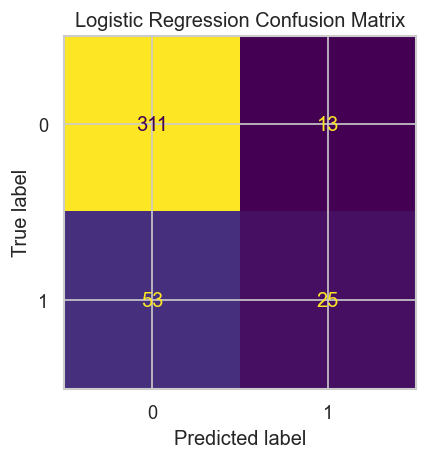

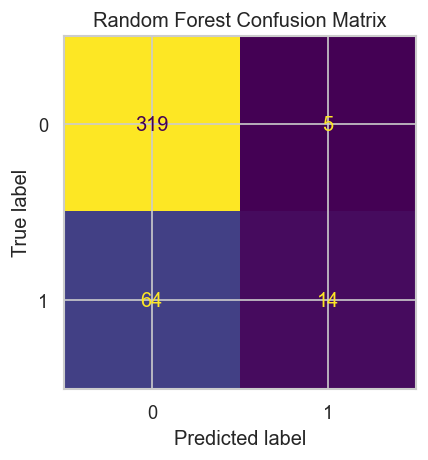

In [11]:
plot_confusion_matrix(logreg_result.evaluation, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(rf_result.evaluation, "Random Forest Confusion Matrix")

## Save Best Model

In [12]:
best_result = (
    rf_result
    if rf_result.evaluation.roc_auc >= logreg_result.evaluation.roc_auc
    else logreg_result
)
best_model_path = MODEL_DIR / f"best_model_{best_result.model_name}.joblib"
save_model(best_result.pipeline, best_model_path)

PosixPath('/Users/thomaspalmeira/Desktop/Dev/Trainings/vibe_coding_training/artifacts/best_model_LogisticRegression.joblib')

## Conclusion

This workflow now follows one deterministic preprocessing and training path for both models. The notebook stays focused on inspection, comparison, and interpretation, while the split, fit, validation, and persistence logic lives in reusable modules under `src/`.